# 6. Resultados e exportação

Resumo dos três modelos e exportação de `src/content/ml/resultados.json`, que é o arquivo lido pela tela de analytics do `/sistema`. Rode os cadernos 1 a 5 antes.

In [1]:
import json
import subprocess
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

sns.set_theme(style='whitegrid')

modelos = []
for nome in ['classificacao', 'regressao', 'clustering']:
    with open(f'../saidas/{nome}.json', encoding='utf-8') as arquivo:
        modelos.append(json.load(arquivo))

pd.DataFrame([
    {'modelo': m['modelo'], **{c: v for c, v in m['metricas'].items() if isinstance(v, (int, float)) and not isinstance(v, bool)}}
    for m in modelos
]).set_index('modelo')

,acuracia,precisao,revocacao,f1,amostras_teste,positivos_no_teste,mae,r2,silhueta,k
modelo,,,,,,,,,,
classificacao,1.0,1.0,1.0,1.0,48.0,22.0,NaN,NaN,NaN,NaN
regressao,NaN,NaN,NaN,NaN,48.0,NaN,0.0044,0.984,NaN,NaN
clustering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.71,4.0


## Classificação

CatBoost, escolhido entre XGBoost, LightGBM, CatBoost e o stacking dos três pelo F1 na validação cruzada em 5 partes. Hiperparâmetros por grid search, peso de classe e separação estratificada de 75% e 25%.

               precision    recall  f1-score   support

  90% ou mais       1.00      1.00      1.00        26
abaixo de 90%       1.00      1.00      1.00        22

     accuracy                           1.00        48
    macro avg       1.00      1.00      1.00        48
 weighted avg       1.00      1.00      1.00        48



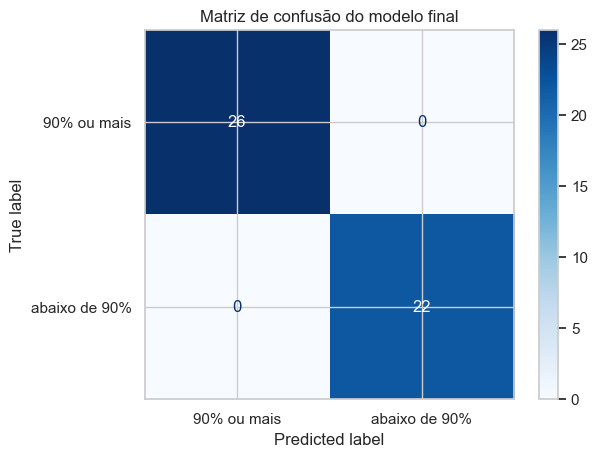

In [2]:
classificacao = pd.read_csv('../saidas/previsoes_classificacao.csv')
print(modelos[0]['metodo'])
print()
print(classification_report(classificacao['real'], classificacao['previsto'], target_names=['90% ou mais', 'abaixo de 90%']))

ConfusionMatrixDisplay.from_predictions(
    classificacao['real'], classificacao['previsto'], display_labels=['90% ou mais', 'abaixo de 90%'], cmap='Blues'
)
plt.title('Matriz de confusão do modelo final')
plt.show()

## Regressão

XGBoost com hiperparâmetros por grid search (500 árvores, profundidade 2). Validação cruzada em 5 partes e separação de 75% e 25%.
MAE: 0.0044 | R²: 0.984 | MAE da média: 0.0701


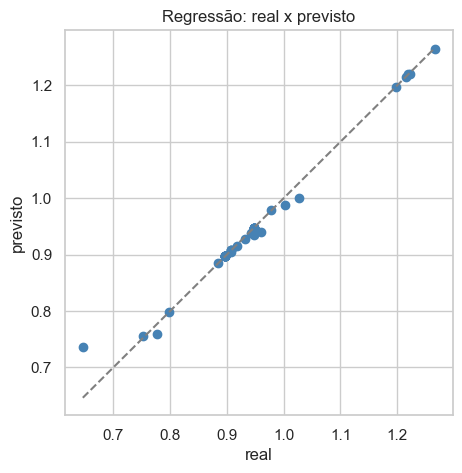

In [3]:
regressao = pd.read_csv('../saidas/previsoes_regressao.csv')
print(modelos[1]['metodo'])
print('MAE:', modelos[1]['metricas']['mae'], '| R²:', modelos[1]['metricas']['r2'], '| MAE da média:', modelos[1]['referencia']['mae'])

plt.figure(figsize=(5, 5))
plt.scatter(regressao['real'], regressao['previsto'], color='steelblue')
limites = [regressao['real'].min(), regressao['real'].max()]
plt.plot(limites, limites, color='gray', linestyle='--')
plt.xlabel('real')
plt.ylabel('previsto')
plt.title('Regressão: real x previsto')
plt.show()

## Clustering

In [4]:
pd.DataFrame(modelos[2]['metricas']['grupos'])

,nome,unidades,resultado_medio
0,grupo 2: maioria MAC,12,1.237
1,grupo 3: maioria USF,73,0.949
2,grupo 1: maioria USF,100,0.893
3,grupo 4: maioria USF,5,0.786


## Exportação para o app

In [5]:
commit = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], capture_output=True, text=True).stdout.strip()

pacote = {
    'gerado_em': date.today().isoformat(),
    'semente': 20262,
    'commit': commit or 'desconhecido',
    'versao_sklearn': sklearn.__version__,
    'base': 'planilha de desempenho por unidade, sem dado de pessoa, tratada em ml/notebooks',
    'aviso': 'Nenhum resultado desta lista entra no cálculo da gratificação.',
    'modelos': modelos,
}

with open('../../src/content/ml/resultados.json', 'w', encoding='utf-8') as arquivo:
    json.dump(pacote, arquivo, ensure_ascii=False, indent=2)
    arquivo.write('\n')

## Conclusões

- **Classificação:** os três modelos de boosting acertam quase todas as unidades do teste, bem acima de chutar a classe mais comum. O CatBoost teve o melhor F1 na validação cruzada (empatado com o stacking) e foi o escolhido. O desvio entre os indicadores é o que mais pesa, seguido do indicador 1 e do produto do indicador 3 pelo indicador 4.
- **Regressão:** o XGBoost prevê o resultado geral com erro muito pequeno, porque o resultado é uma soma ponderada das notas. O indicador 3 é o que mais pesa, porque é o que mais varia entre os tipos de unidade.
- **Clustering:** os grupos seguem principalmente o tipo de unidade.
- Na limpeza apareceram 6 linhas (NDI e SAE) em que a planilha não segue os pesos da portaria. É o tipo de erro que um sistema que calcula a partir da regra evita.
- Nenhum resultado destes modelos entra no cálculo da gratificação: eles servem para mostrar onde olhar, e a regra da portaria continua decidindo o valor.